# Тестовый срез модуля №1

## Импорт нужных библиотек

In [394]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.decomposition import PCA
from sklearn import tree

## Задание 1.1. Создание объекта DataFrame для работы с данными датасета и сохранение "грязного" датасета в базу данных.

### Чтение датасета с обработчиком исключений (запись в две переменные на всякий случай)

In [395]:
try:
    data = pd.read_csv("healthcare_dataset.csv")
    copy_data = pd.read_csv("healthcare_dataset.csv")
except Exception as e:
    print(f"Ошибка загрузки набора данных:\n{e}")

### Сохранение "грязного" датасета в базу данных

In [396]:
try:
    con = sqlite3.connect("test.db")
    data.to_sql("dirty_data", con=con, if_exists="append", index=False)
except Exception as e:
    print(f"Ошибка загрузки набора данных в базу данных:\n{e}")

## Задание 1.2. Подготовка датасета к кластерному анализу. Проведение кластерного анализа.

### Проверка на пустые значения и NaN

In [397]:
data.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Замена строковых значений на численные для будущей обработки данных моделью и удаление не нужных столбцов с большим количеством кникальных значений

In [398]:
data["Medical Condition"].unique()

array(['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension',
       'Arthritis'], dtype=object)

In [399]:
data["Medical Condition"] = data["Medical Condition"].map({'Cancer': 0, 'Obesity': 1, 'Diabetes': 2, 'Asthma': 3, 'Hypertension': 4, 'Arthritis': 5})

In [400]:
data["Blood Type"].unique()

array(['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-'], dtype=object)

In [401]:
data["Blood Type"] = data["Blood Type"].map({'B-': 0, 'A+': 1, 'A-': 2, 'O+': 3, 'AB+': 4, 'AB-': 5, 'B+': 6, 'O-': 7})

In [402]:
data["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [403]:
data["Gender"] = data["Gender"].map({'Male': 0, 'Female': 1})

In [404]:
data["Insurance Provider"].unique()

array(['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna'],
      dtype=object)

In [405]:
data["Insurance Provider"] = data["Insurance Provider"].map({'Blue Cross': 0, 'Medicare': 1, 'Aetna': 2, 'UnitedHealthcare': 3, 'Cigna': 4})

In [406]:
data["Admission Type"].unique()

array(['Urgent', 'Emergency', 'Elective'], dtype=object)

In [407]:
data["Admission Type"] = data["Admission Type"].map({'Urgent': 0, 'Emergency': 1, 'Elective': 2})

In [408]:
data["Medication"].unique()

array(['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor'],
      dtype=object)

In [409]:
data["Medication"] = data["Medication"].map({'Paracetamol': 0, 'Ibuprofen': 1, 'Aspirin': 2, 'Penicillin': 3, 'Lipitor': 4})

In [410]:
data["Test Results"].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

In [411]:
data["Test Results"] = data["Test Results"].map({'Normal': 0, 'Inconclusive': 1, 'Abnormal': 2})

In [412]:
data = data.drop(["Name", "Doctor","Hospital", "Date of Admission", "Discharge Date"], axis=1)

### Проведение кластерного анализа

#### Уменьшение размерности датасета

In [413]:
pca = PCA(n_components=2) # Создаем объект PCA, который позволит снизить размерность данных до 2-хмерной
data_2d = pca.fit_transform(data) # Снижаем размерность DataSet и записываем в переменную data_2d

#### Создаем 3 модели для кластерного анализа, чтобы выбрать лучшую, и обучаем их на датасете

In [414]:
kmeans = KMeans(n_clusters=5) # Создаем объект модели KMeans, который расспределит данные по кластерам
db = DBSCAN() # Создаем объект модели DBSCAN, который расспределит данные по кластерам
hb = HDBSCAN() # Создаем объект модели HDBSCAN, который расспределит данные по кластерам

In [415]:
kmeans.fit(data_2d) # Обучаем модель KMeans на данных из переменной data_2d

KMeans(n_clusters=5)

In [416]:
db.fit(data_2d)

DBSCAN()

In [417]:
hb.fit(data_2d)

HDBSCAN()

#### Прогоняем через обученные датасеты изначальный датасет, не со сниженным размером, и смотрим что получилось на графиках

In [418]:
labels_db = db.fit_predict(data)
labels_hb = hb.fit_predict(data)
labels_km = kmeans.fit_predict(data) # Проводим данные DataSet'а, записанного в переменную data через модель KMeans
# и записываем результат в переменную, получая кластеры

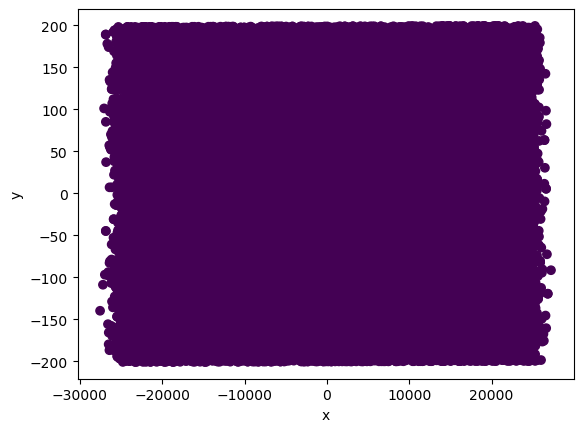

In [419]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels_db, cmap='viridis') # Создаем график для визуализации результата работы модели DBSCAN
plt.xlabel('x') # Называем ось x
plt.ylabel('y') # Называем ось y
plt.show() # Выводим график с кластерами на экран

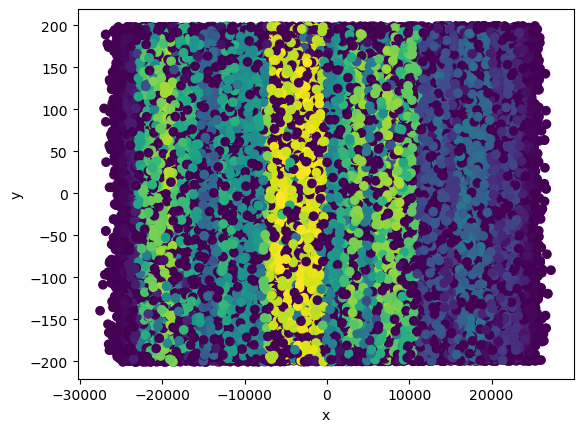

In [420]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels_hb, cmap='viridis') # Создаем график для визуализации результата работы модели HDBSCAN
plt.xlabel('x') # Называем ось x
plt.ylabel('y') # Называем ось y
plt.show() # Выводим график с кластерами на экран

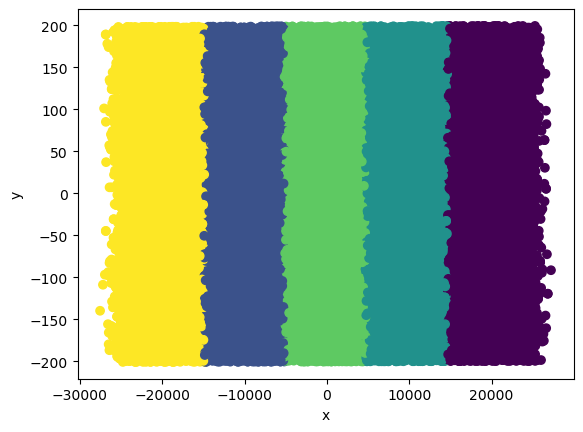

In [421]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels_km, cmap='viridis') # Создаем график для визуализации результата работы модели KMeans
plt.xlabel('x') # Называем ось x
plt.ylabel('y') # Называем ось y
plt.show() # Выводим график с кластерами на экран

#### Самой лучшей оказалась модель KMeans, т.к он четче всех распределила кластеры

In [422]:
labels = pd.Series(labels_km)

In [423]:
labels.name = "Cluster" # Добавляем имя Series, чтобы потом это имя перенеслось в таблицу
data = pd.concat([data, labels], axis=1) # Соединяем Series в кластерами и таблицу

## Задание 1.3. Создание информационной таблички в редакторе таблиц. Проверка расспределений данных в атрибутах.

### Смотрим на зараннее созданную таблицу

In [424]:
inf_table = pd.read_csv("information_table.csv")

In [425]:
inf_table

,Название столбца,Пепревод,Описание,Тип данных,Единицы измерения,Unnamed: 5
0,Age,Возраст,Возраст пациента на момент поступления,Целочисленный,Год,NaN
1,Gender,Пол,Указывает пол пациента,Целочисленный,-,NaN
2,Blood Type,Тип крови,"Группа крови пациента, которая может быть одно...",Целочисленный,-,NaN
3,Medical Condition,Медицинское заключение,В этом столбце указывается основное медицинско...,Целочисленный,-,NaN
4,Insurance Provider,Поставщик услуг страхования,В этом столбце указывается страховая компания ...,Целочисленный,-,NaN
5,Billing Amount,Сумма выставления счета,"Сумма денег, выставленная за медицинские услуг...",Число с плавующей точкой,Валюта,NaN
6,Room Number,Номер комнаты,"Номер палаты, в которой находился пациент во в...",Целочисленный,-,NaN
7,Admission Type,Тип допуска,Определяет тип допуска,Целочисленный,-,NaN
8,Medication,Лечение,"Определяет лекарственное средство, назначенное...",Целочисленный,-,NaN
9,Test Results,Результаты тестирования,Описывает результаты медицинского обследования...,Целочисленный,-,NaN


### Создаем графики для каждого атрибута, смотрим расспределние данных на них

#### Там, где значений много я выбирал гистограмму, там где мало столбчатую диаграмму

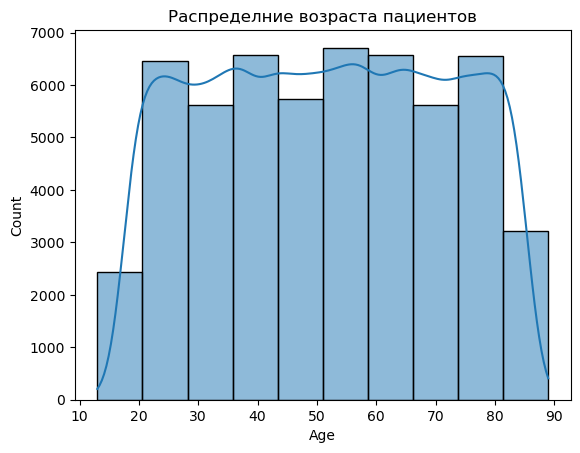

In [426]:
sb.histplot(data['Age'], bins=10, kde=True)
plt.title('Распределние возраста пациентов')
plt.show()

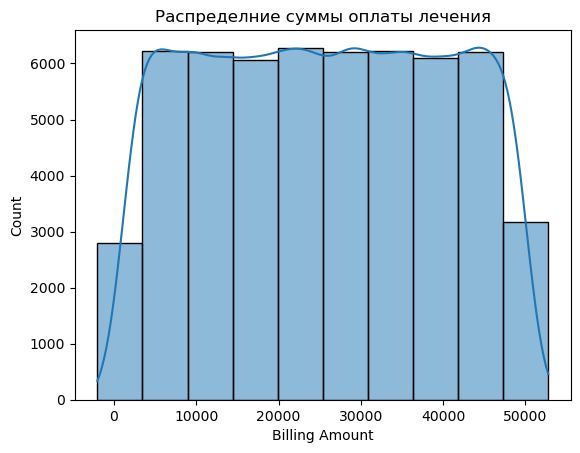

In [427]:
sb.histplot(data['Billing Amount'], bins=10, kde=True)
plt.title('Распределние суммы оплаты лечения')
plt.show()

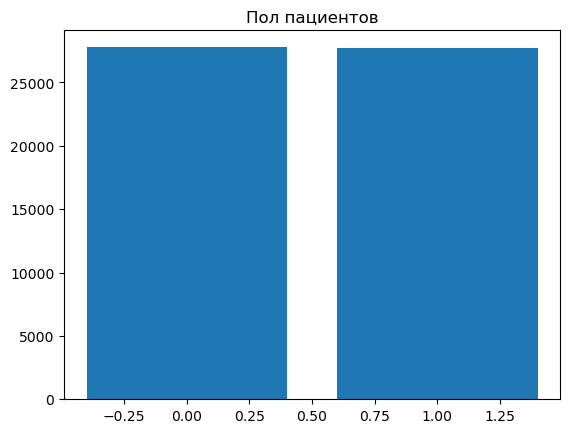

In [428]:
plt.bar(data["Gender"].unique(), data["Gender"].value_counts())
plt.title('Пол пациентов')
plt.show()

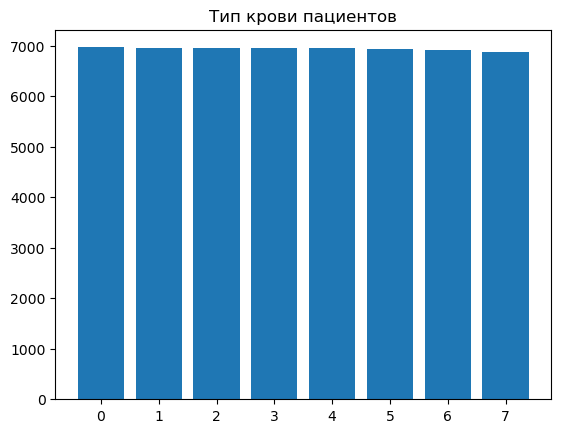

In [429]:
plt.bar(data["Blood Type"].unique(), data["Blood Type"].value_counts())
plt.title('Тип крови пациентов')
plt.show()

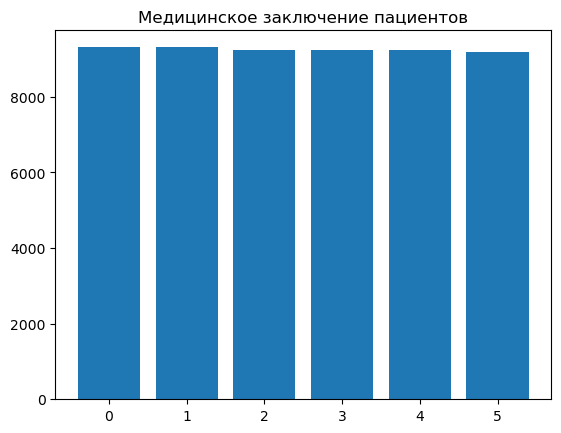

In [430]:
plt.bar(data["Medical Condition"].unique(), data["Medical Condition"].value_counts())
plt.title('Медицинское заключение пациентов')
plt.show()

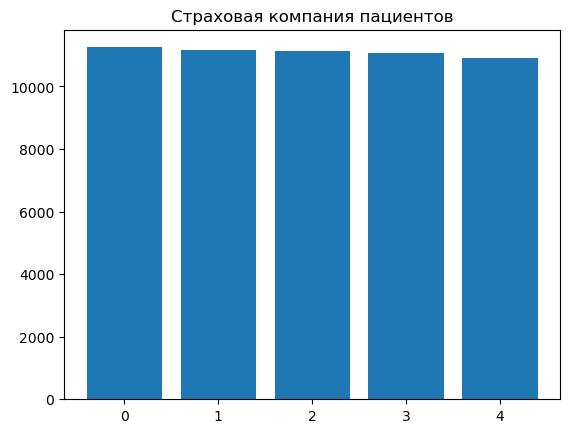

In [431]:
plt.bar(data["Insurance Provider"].unique(), data["Insurance Provider"].value_counts())
plt.title('Страховая компания пациентов')
plt.show()

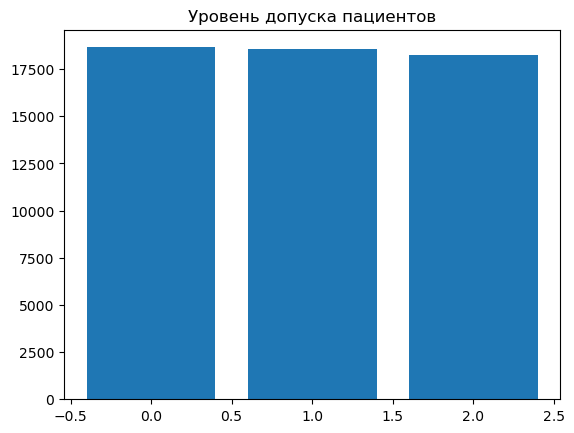

In [432]:
plt.bar(data["Admission Type"].unique(), data["Admission Type"].value_counts())
plt.title('Уровень допуска пациентов')
plt.show()

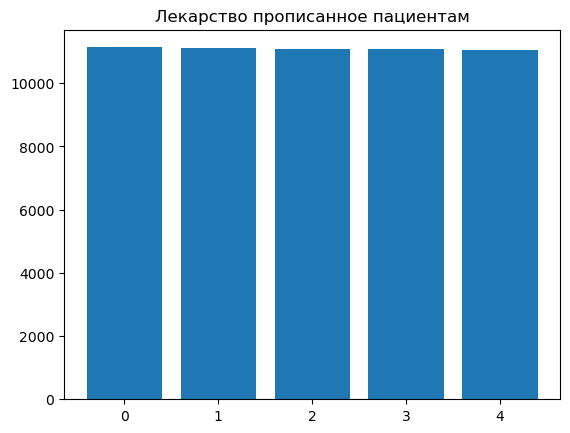

In [433]:
plt.bar(data["Medication"].unique(), data["Medication"].value_counts())
plt.title('Лекарство прописанное пациентам')
plt.show()

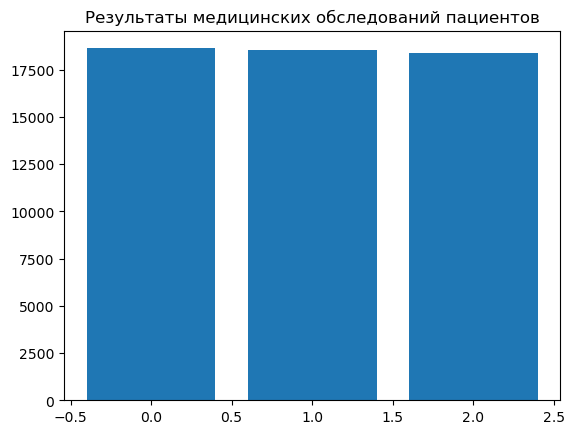

In [434]:
plt.bar(data["Test Results"].unique(), data["Test Results"].value_counts())
plt.title('Результаты медицинских обследований пациентов')
plt.show()

#### Расспределение значений в атрибутах равномерное, без резких изменений данных

## Задание 1.4. Выполнение заданий

### Задание 1.4.1. Так как атрибут "Hospital" нам не нужен везде кроме этого задания я его удалил еще в начале, при первоначальной чистке. Сейчас я временно для выполнения заданий скопирую этот отрибут из копии первоначального датасета и потом удалю его в конце выполнения заданий.

In [435]:
data["Hospital"] = copy_data["Hospital"]

In [436]:
mean_bill_hosp = data.groupby("Hospital")["Billing Amount"].mean()

In [437]:
mean_bill_hosp

Hospital
Abbott Inc                       38052.041917
Abbott Ltd                       29877.586483
Abbott Moore and Williams,       24799.596339
Abbott and Thompson, Sullivan    16738.569765
Abbott, Peters and Hoffman       18842.396863
                                     ...     
and Zimmerman Sons               32706.652625
and Zuniga Davis Carlson,        42867.041298
and Zuniga Francis Peterson,     33689.630726
and Zuniga Sons                  33950.170483
and Zuniga Thompson, Blake       22067.428763
Name: Billing Amount, Length: 39876, dtype: float64

#### Задание 1.4.2

In [438]:
mean_bill_hosp / (data["Billing Amount"].mean() /  100)

Hospital
Abbott Inc                       148.993974
Abbott Ltd                       116.986635
Abbott Moore and Williams,        97.103604
Abbott and Thompson, Sullivan     65.540399
Abbott, Peters and Hoffman        73.778001
                                    ...    
and Zimmerman Sons               128.063933
and Zuniga Davis Carlson,        167.847256
and Zuniga Francis Peterson,     131.912815
and Zuniga Sons                  132.932966
and Zuniga Thompson, Blake        86.405715
Name: Billing Amount, Length: 39876, dtype: float64

### Задание 1.4.3

In [439]:
data.groupby("Room Number")["Age"].count()

Room Number
101    122
102    159
103    137
104    175
105    118
      ... 
496    168
497    144
498    139
499    126
500    127
Name: Age, Length: 400, dtype: int64

### Задание 1.4.4

In [440]:
data.groupby(["Room Number", "Hospital"])["Billing Amount"].mean()

Room Number  Hospital                    
101          Adams Smith Cervantes, and      43564.769710
             Anderson Wright, and Lucas      37133.117086
             Beasley-Ellison                 41572.381658
             Bowman-Weaver                   28559.457709
             Brewer PLC                      32606.364556
                                                 ...     
500          and Gonzalez Smith, Miller       3970.759579
             and Hoffman Blake Hernandez,     7183.539481
             and Jackson Brown Green,        45753.528634
             and Maynard Anderson Bender,    30153.548341
             and Wells Mcdonald Frye,        20057.243734
Name: Billing Amount, Length: 49921, dtype: float64

### Задания выполнены, удаляем атрибут "Hospital"

In [441]:
data=data.drop("Hospital", axis=1)

## Задание 1.5. Очистка набора от ненужных атрибутов для будущего обучения моделей. "Таргетом" был взят атрибут "Insurance Provider"

### Обучаем простую модель, с целью понять какие атрибуты она будет использовать в своем обучении, а какие нет

In [442]:
y = data["Insurance Provider"] # Выделяем интересующую цель, которую модель будет предсказывать
x = data[data.columns[data.columns != "Insurance Provider"]] # В входные данные для модели пойдут все, помимо предсказываемой
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # С помощью метода train_test_split
# делим данные на выборки: тестовую (20 процентов от всех данных) и тренировочную (80 процентов от всех данных)

clf = tree.DecisionTreeClassifier() # Создаем объект модели DecisionTreeClassifier

In [443]:
clf.fit(X_train, y_train) # Тренируем модель на тренировочных данных

DecisionTreeClassifier()

### Визуализируем коэффиценты, чтобы было удобно выбрабрать самые маленькие

In [444]:
clf.feature_importances_ # Получаем массив, по которому можно понять, какие данные использовала модель

array([0.16750561, 0.03303839, 0.10130988, 0.08556674, 0.23148245,
       0.18765638, 0.04771461, 0.07567438, 0.05743802, 0.01261354])

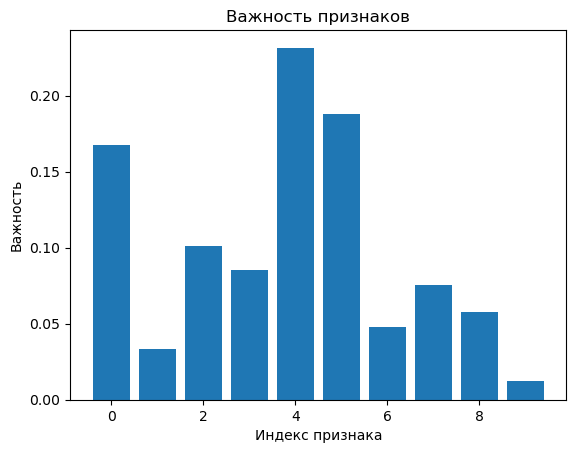

In [445]:
plt.bar(range(len(clf.feature_importances_)), clf.feature_importances_)
plt.xlabel('Индекс признака')
plt.ylabel('Важность')
plt.title('Важность признаков')
plt.show()

### Для сравнения и наглядности создаем матрицу корреляции

In [446]:
cor_matrix = data.corr() # С помощью метода .corr() считаем значения для матрицы корреляции

<Axes: >

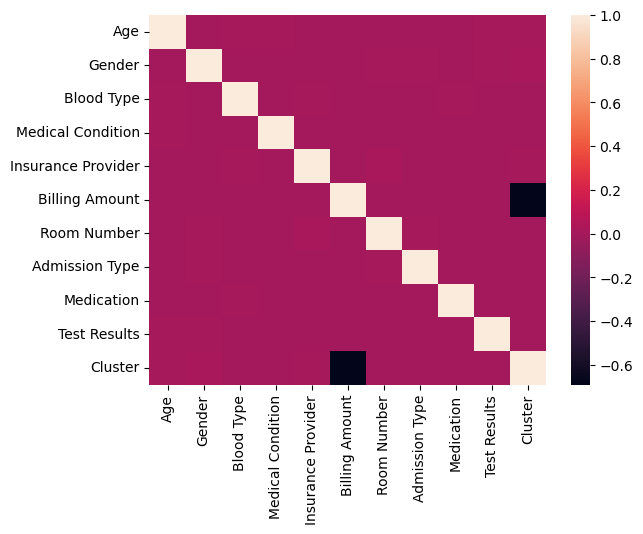

In [447]:
sb.heatmap(cor_matrix) # Выводим матрицу корреляции на экран

### Смотря на полученные данные, удаляем самые мало влияющие на таргет атрибуты

#### В виде исключения оставляем атрибут с кластерами, так как он нам еще пригодится в следущих заданиях

In [448]:
data=data.drop(X_train.columns[[2,6,7,4]], axis=1)

#### Смотрим на "чистый" датасет

In [449]:
data

,Age,Gender,Medical Condition,Insurance Provider,Room Number,Test Results,Cluster
0,30,0,0,0,328,0,1
1,62,0,1,1,265,1,2
2,76,1,1,2,205,0,3
3,28,1,2,1,450,2,2
4,43,1,0,2,458,2,1
...,...,...,...,...,...,...,...
55495,42,1,3,0,417,2,4
55496,61,1,1,4,316,0,2
55497,38,1,4,3,347,2,3
55498,43,0,5,1,321,2,2


### Обновляем базу данных новым, обработанным датасетом и сохраняем его же в .csv файл

In [452]:
try:
    data.to_sql("clean_data", con=con, if_exists="append", index=False)
except Exception as e:
    print(f"Ошибка загрузки чистого набора данных в базу данных:\n{e}")

Ошибка загрузки чистого набора данных в базу данных:
table clean_data has no column named Cluster


In [453]:
data.to_csv("clean_healthcare_dataset.csv")

# Дополнительное задание

In [457]:
import gpxpy
import os

In [477]:
bike_0 = pd.DataFrame()
bike_1 = pd.DataFrame()
bike_2 = pd.DataFrame()
bike_3 = pd.DataFrame()
count = 0
lat = []
long = []

In [478]:
with open("GPX file/bike/Laramie_Enduro_2014..gpx", "r") as file:
    gpx = gpxpy.parse(file)
for waypoint in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            lat.append(point.latitude)
            long.append(point.longitude)
bike["lat"] = lat
bike["long"] = long

In [479]:
bike

,lat,long
0,41.321687,-105.574593
1,41.321723,-105.574663
2,41.321735,-105.574711
3,41.321733,-105.574753
4,41.321711,-105.574792
...,...,...
28884,41.321659,-105.574792
28885,41.321688,-105.574785
28886,41.321795,-105.574816
28887,41.321755,-105.574809
